# 01 — Exploratory Data Analysis
### Twitter US Airline Sentiment

**Sections:**
1. Load data & basic stats
2. Class imbalance deep dive
3. Sentiment by airline
4. Negative reasons analysis
5. Tweet length & word count analysis
6. Temporal analysis (when do complaints peak?)
7. Vocabulary overlap analysis
8. Correlation analysis
9. Confidence score analysis
10. Word clouds
11. Key business insights summary


## 1. Setup & Load

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
PALETTE = {"negative":"#E24B4A","neutral":"#888780","positive":"#1D9E75"}

df = pd.read_csv("../data/tweets_clean.csv")
df["tweet_created"] = pd.to_datetime(df["tweet_created"], utc=True)
print(f"Loaded {len(df):,} rows | {len(df.columns)} columns")
df.head(3)

Loaded 14,582 rows | 15 columns


,tweet_id,text,airline_sentiment,airline_sentiment_confidence,airline,negativereason,negativereason_confidence,tweet_created,retweet_count,clean_text,no_stop_text,stemmed_text,lemmatized_text,final_text,label
0,570306133677760513,@VirginAmerica What @dhepburn said.,neutral,1.0000,Virgin America,Not Applicable,NaN,2015-02-24 19:35:52+00:00,0,what said,said,what said,what said,what said,1
1,570301130888122368,@VirginAmerica plus you've added commercials t...,positive,0.3486,Virgin America,Not Applicable,0.0,2015-02-24 19:15:59+00:00,0,plus youve added commercials to the experience...,plus youve added commercials experience tacky,plu youv ad commerci to the experi tacki,plus youve added commercial to the experience ...,plus youve added commercial to the experience ...,2
2,570301083672813571,@VirginAmerica I didn't today... Must mean I n...,neutral,0.6837,Virgin America,Not Applicable,NaN,2015-02-24 19:15:48+00:00,0,i didnt today must mean i need to take another...,didnt today must mean need take another trip!,i didnt today must mean i need to take anoth t...,i didnt today must mean i need to take another...,i didnt today must mean i need to take another...,1


## 2. Class Imbalance Deep Dive

Imbalanced classes are one of the most common problems in real-world ML.
Understanding the imbalance helps us choose the right strategy to handle it.


airline_sentiment
negative    9174
neutral     3055
positive    2353
Name: count, dtype: int64


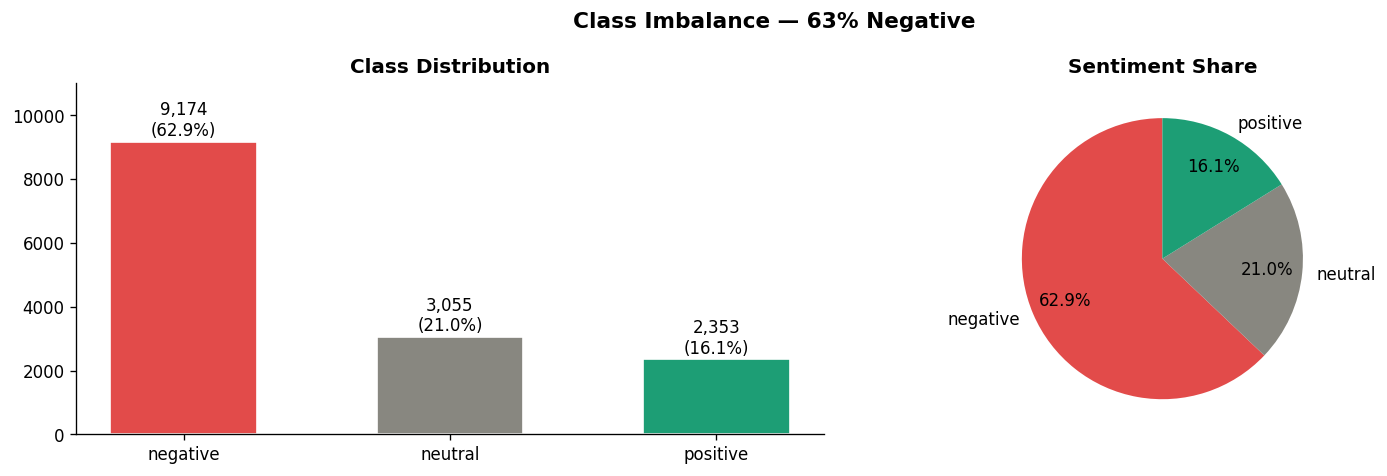

Imbalance ratios:
  negative     1.00x minority ratio
  neutral      3.00x minority ratio
  positive     3.90x minority ratio

💡 A naive model predicting always 'negative' gets 62.9% accuracy.
   Our target: meaningfully beat this baseline.


In [15]:
counts = df["airline_sentiment"].value_counts().reindex(["negative","neutral","positive"])
total  = len(df)
print(counts)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[s] for s in counts.index],
                   edgecolor="white", width=0.55)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 f"{count:,}\n({count/total*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylim(0, counts.max()*1.2)
axes[0].spines[["top","right"]].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[PALETTE[s] for s in counts.index],
            startangle=90, pctdistance=0.75)
axes[1].set_title("Sentiment Share", fontweight="bold")

plt.suptitle("Class Imbalance — 63% Negative", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

# Imbalance ratio
majority = counts.max()
print("Imbalance ratios:")
for s, c in counts.items():
    print(f"  {s:<12} {majority/c:.2f}x minority ratio")
print()
print("💡 A naive model predicting always 'negative' gets 62.9% accuracy.")
print("   Our target: meaningfully beat this baseline.")

## 3. Sentiment by Airline

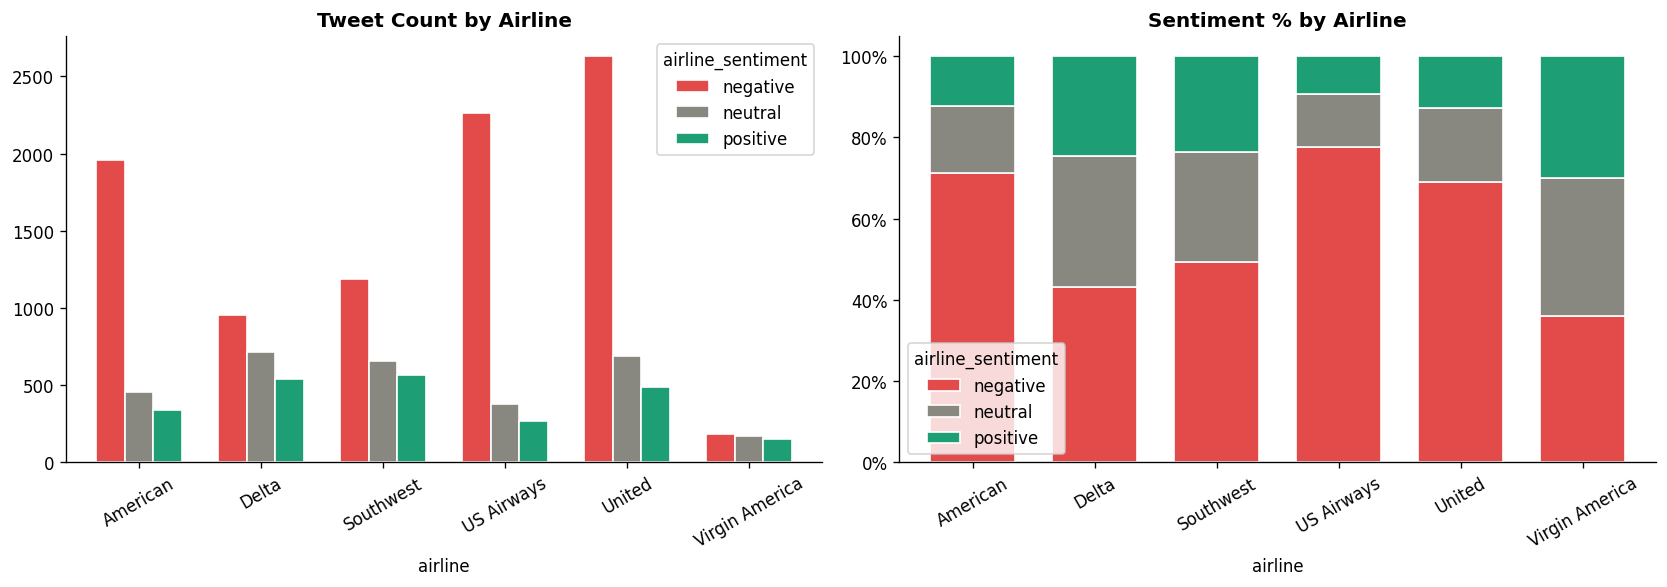

Negative rate per airline:
  US Airways           78% negative
  American             71% negative
  United               69% negative
  Southwest            49% negative
  Delta                43% negative
  Virgin America       36% negative


In [3]:
pivot = (df.groupby(["airline","airline_sentiment"])
           .size().unstack(fill_value=0)
           .reindex(columns=["negative","neutral","positive"]))

pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot.plot(kind="bar", ax=axes[0],
           color=[PALETTE[s] for s in ["negative","neutral","positive"]],
           edgecolor="white", width=0.7)
axes[0].set_title("Tweet Count by Airline", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)
axes[0].spines[["top","right"]].set_visible(False)

pct.plot(kind="bar", stacked=True, ax=axes[1],
         color=[PALETTE[s] for s in ["negative","neutral","positive"]],
         edgecolor="white", width=0.7)
axes[1].set_title("Sentiment % by Airline", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/01_airline_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

print("Negative rate per airline:")
for airline in pct.sort_values("negative", ascending=False).index:
    print(f"  {airline:<20} {pct.loc[airline,'negative']:.0f}% negative")

## 4. Negative Reasons Analysis

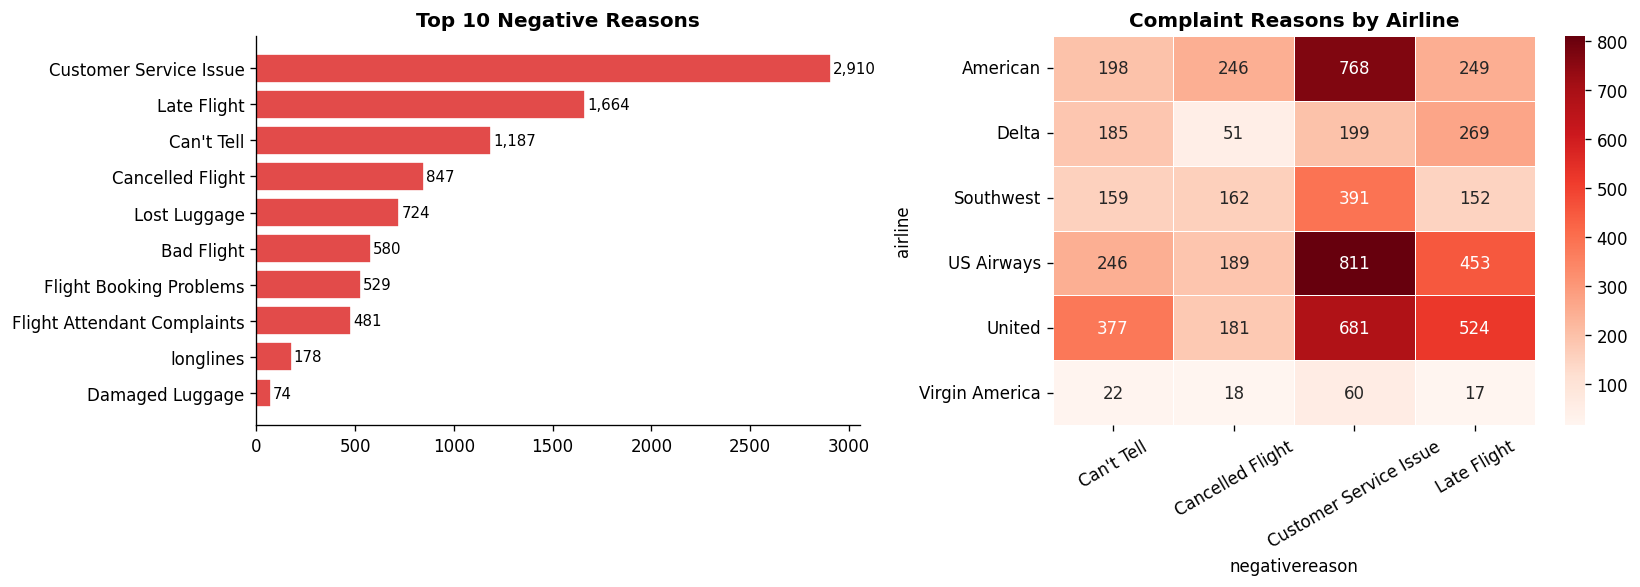

In [4]:
# Top reasons overall
reasons = (df[df["airline_sentiment"]=="negative"]["negativereason"]
             .value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
axes[0].barh(reasons.index[::-1], reasons.values[::-1],
             color="#E24B4A", edgecolor="white")
for i, (idx, val) in enumerate(zip(reasons.index[::-1], reasons.values[::-1])):
    axes[0].text(val+10, i, f"{val:,}", va="center", fontsize=9)
axes[0].set_title("Top 10 Negative Reasons", fontweight="bold")
axes[0].spines[["top","right"]].set_visible(False)

# Heatmap by airline
reason_airline = (df[df["airline_sentiment"]=="negative"]
                    .groupby(["airline","negativereason"])
                    .size().unstack(fill_value=0))
top5 = df["negativereason"].value_counts().head(5).index
reason_airline = reason_airline[reason_airline.columns.intersection(top5)]
sns.heatmap(reason_airline, annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, linecolor="white", ax=axes[1])
axes[1].set_title("Complaint Reasons by Airline", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../outputs/01_negative_reasons.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Tweet Length Analysis

Word count statistics by sentiment:
                    mean  median   std  min  max
airline_sentiment                               
negative           17.96    19.0  5.83    1   31
neutral            12.82    12.0  6.83    1   30
positive           12.49    12.0  6.88    1   30


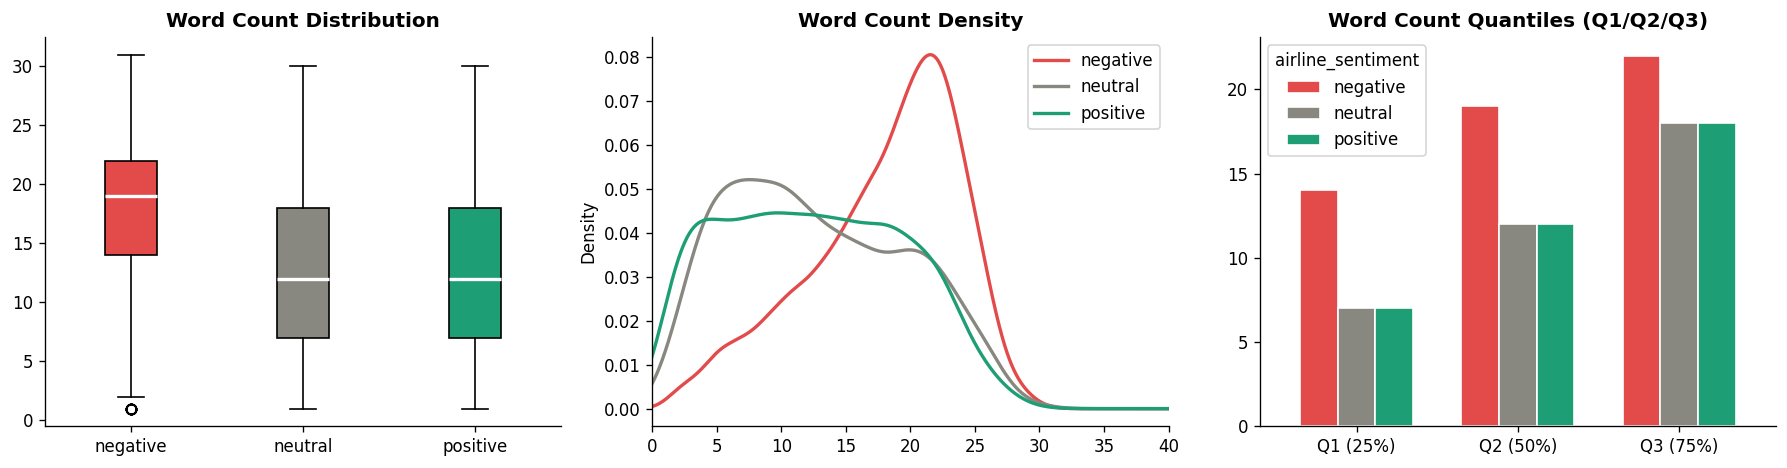

In [5]:
df["word_count"] = df["final_text"].str.split().str.len()
df["char_count"] = df["final_text"].str.len()

# Stats per sentiment
print("Word count statistics by sentiment:")
print(df.groupby("airline_sentiment")["word_count"]
        .agg(["mean","median","std","min","max"]).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = ["negative","neutral","positive"]

# Boxplot
data = [df[df["airline_sentiment"]==s]["word_count"] for s in order]
bp = axes[0].boxplot(data, labels=order, patch_artist=True,
                     medianprops=dict(color="white",linewidth=2))
for patch, s in zip(bp["boxes"], order):
    patch.set_facecolor(PALETTE[s])
axes[0].set_title("Word Count Distribution", fontweight="bold")
axes[0].spines[["top","right"]].set_visible(False)

# KDE
for s in order:
    df[df["airline_sentiment"]==s]["word_count"].plot.kde(
        ax=axes[1], color=PALETTE[s], linewidth=2, label=s)
axes[1].set_title("Word Count Density", fontweight="bold")
axes[1].legend(); axes[1].set_xlim(0,40)
axes[1].spines[["top","right"]].set_visible(False)

# Quantiles
quantiles = df.groupby("airline_sentiment")["word_count"].quantile([0.25,0.5,0.75]).unstack()
quantiles.T.plot(kind="bar", ax=axes[2],
                 color=[PALETTE[s] for s in quantiles.index],
                 edgecolor="white", width=0.7)
axes[2].set_title("Word Count Quantiles (Q1/Q2/Q3)", fontweight="bold")
axes[2].set_xticklabels(["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"], rotation=0)
axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/01_tweet_length.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Temporal Analysis

When do negative tweets peak?
Are complaints higher on certain days or hours?
This kind of time-based insight is valuable for business decisions
(e.g. when to staff more customer service agents).


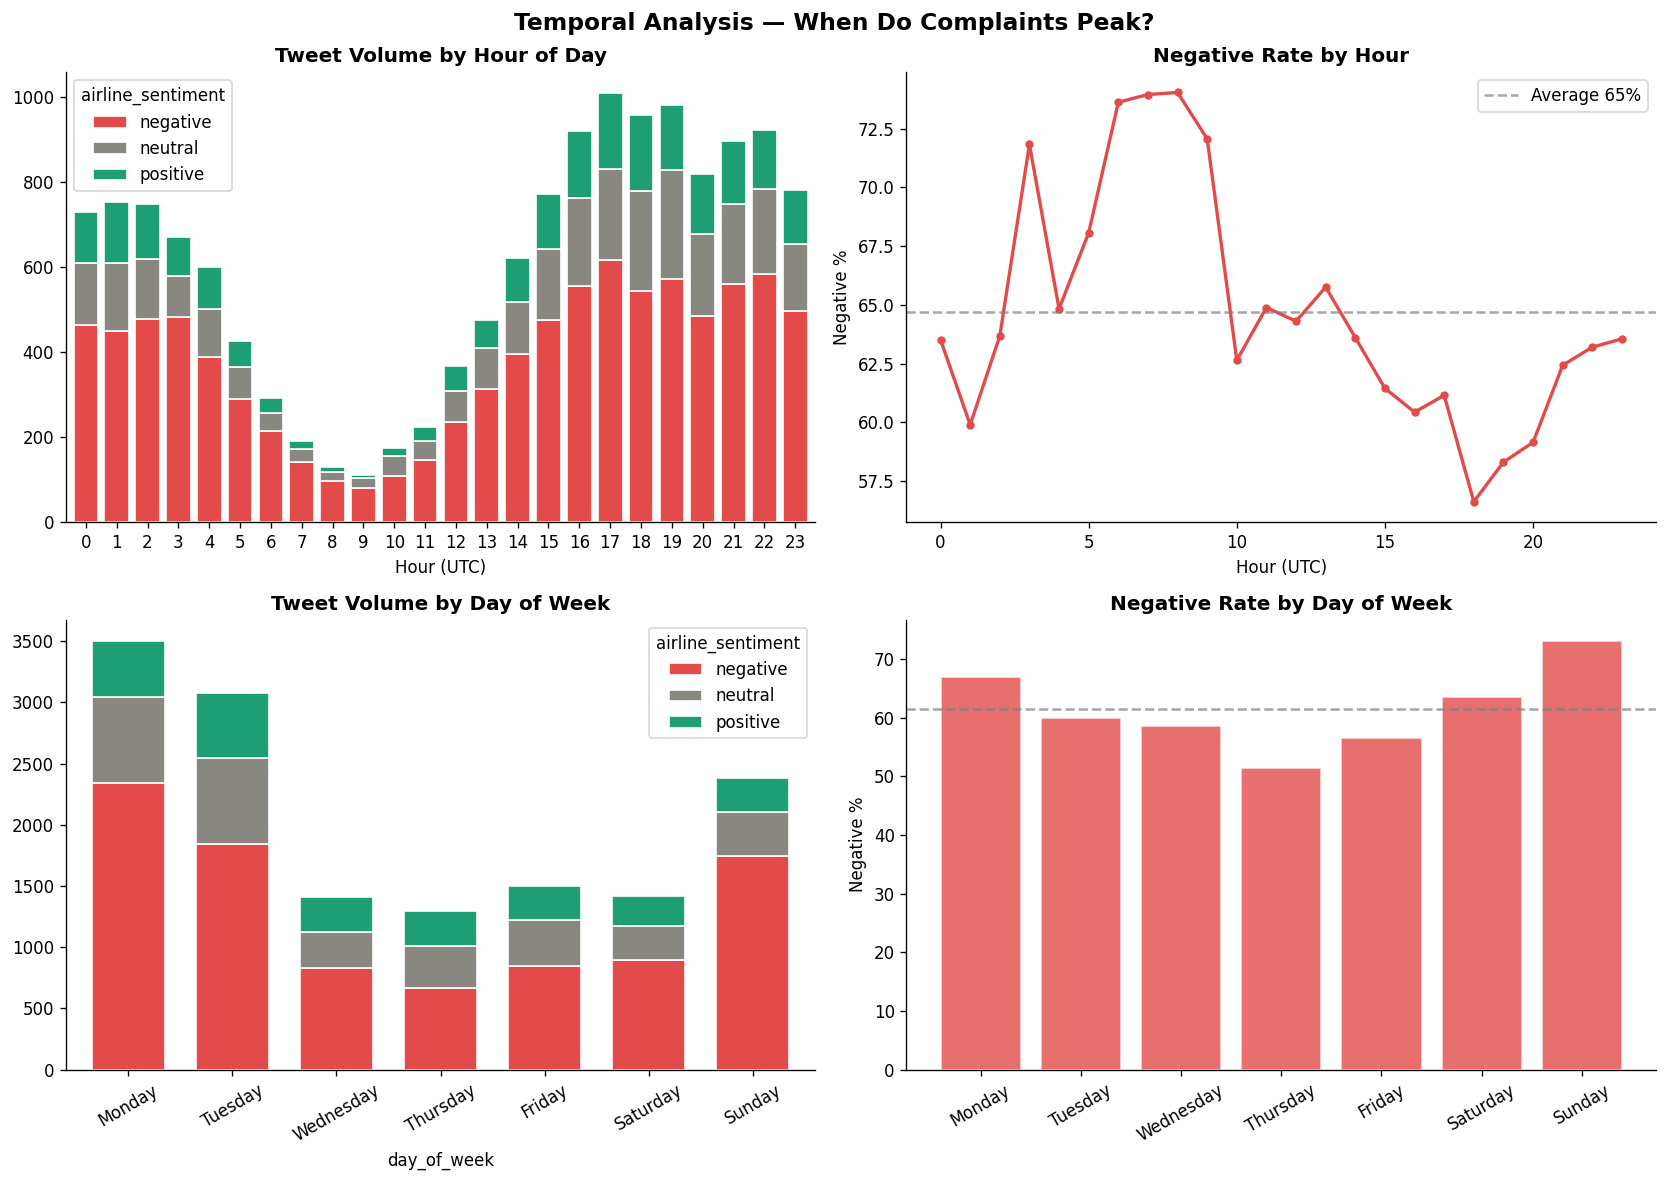

Peak complaint hour : 8:00 UTC (74% negative)
Peak complaint day  : Sunday (73% negative)


In [6]:
df["hour"]       = df["tweet_created"].dt.hour
df["day_of_week"] = df["tweet_created"].dt.day_name()
df["date"]       = df["tweet_created"].dt.date

DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tweets by hour
hour_counts = df.groupby(["hour","airline_sentiment"]).size().unstack(fill_value=0)
hour_counts.reindex(columns=["negative","neutral","positive"]).plot(
    kind="bar", ax=axes[0][0], stacked=True,
    color=[PALETTE[s] for s in ["negative","neutral","positive"]],
    edgecolor="white", width=0.8)
axes[0][0].set_title("Tweet Volume by Hour of Day", fontweight="bold")
axes[0][0].set_xlabel("Hour (UTC)")
axes[0][0].tick_params(axis="x", rotation=0)
axes[0][0].spines[["top","right"]].set_visible(False)

# Negative rate by hour
neg_rate_hour = (df.groupby("hour")["airline_sentiment"]
                   .apply(lambda x: (x=="negative").mean()*100))
axes[0][1].plot(neg_rate_hour.index, neg_rate_hour.values,
                color="#E24B4A", linewidth=2, marker="o", markersize=4)
axes[0][1].axhline(y=neg_rate_hour.mean(), color="gray",
                   linestyle="--", alpha=0.7, label=f"Average {neg_rate_hour.mean():.0f}%")
axes[0][1].set_title("Negative Rate by Hour", fontweight="bold")
axes[0][1].set_xlabel("Hour (UTC)"); axes[0][1].set_ylabel("Negative %")
axes[0][1].legend(); axes[0][1].spines[["top","right"]].set_visible(False)

# Tweets by day
day_counts = df.groupby(["day_of_week","airline_sentiment"]).size().unstack(fill_value=0)
day_counts = day_counts.reindex(DAY_ORDER)
day_counts[["negative","neutral","positive"]].plot(
    kind="bar", ax=axes[1][0], stacked=True,
    color=[PALETTE[s] for s in ["negative","neutral","positive"]],
    edgecolor="white", width=0.7)
axes[1][0].set_title("Tweet Volume by Day of Week", fontweight="bold")
axes[1][0].tick_params(axis="x", rotation=30)
axes[1][0].spines[["top","right"]].set_visible(False)

# Negative rate by day
neg_rate_day = (df.groupby("day_of_week")["airline_sentiment"]
                  .apply(lambda x: (x=="negative").mean()*100)
                  .reindex(DAY_ORDER))
axes[1][1].bar(DAY_ORDER, neg_rate_day.values,
               color="#E24B4A", alpha=0.8, edgecolor="white")
axes[1][1].axhline(y=neg_rate_day.mean(), color="gray",
                   linestyle="--", alpha=0.7)
axes[1][1].set_title("Negative Rate by Day of Week", fontweight="bold")
axes[1][1].set_ylabel("Negative %")
axes[1][1].tick_params(axis="x", rotation=30)
axes[1][1].spines[["top","right"]].set_visible(False)

plt.suptitle("Temporal Analysis — When Do Complaints Peak?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Peak complaint hour : {neg_rate_hour.idxmax()}:00 UTC ({neg_rate_hour.max():.0f}% negative)")
print(f"Peak complaint day  : {neg_rate_day.idxmax()} ({neg_rate_day.max():.0f}% negative)")

## 7. Vocabulary Overlap Analysis

How much vocabulary is shared between sentiment classes?
High overlap means the classes are harder to distinguish — 
the model has to pick up on subtle word usage patterns.
Low overlap means clear distinctive vocabulary — easier classification.

This directly predicts how hard the classification task is.


In [7]:
def get_vocab(sentiment):
    text = " ".join(df[df["airline_sentiment"]==sentiment]["final_text"].dropna())
    return set(text.split())

neg_vocab = get_vocab("negative")
neu_vocab = get_vocab("neutral")
pos_vocab = get_vocab("positive")
all_vocab = neg_vocab | neu_vocab | pos_vocab

# Overlap matrix
pairs = [
    ("neg∩neu", neg_vocab & neu_vocab),
    ("neg∩pos", neg_vocab & pos_vocab),
    ("neu∩pos", neu_vocab & pos_vocab),
    ("all three", neg_vocab & neu_vocab & pos_vocab),
]

print("Vocabulary sizes:")
print(f"  Negative : {len(neg_vocab):,} unique words")
print(f"  Neutral  : {len(neu_vocab):,} unique words")
print(f"  Positive : {len(pos_vocab):,} unique words")
print(f"  Total    : {len(all_vocab):,} unique words")
print()
print("Vocabulary overlap:")
for name, overlap in pairs:
    pct = len(overlap)/len(all_vocab)*100
    print(f"  {name:<15} {len(overlap):,} words  ({pct:.1f}% of total vocabulary)")

Vocabulary sizes:
  Negative : 9,733 unique words
  Neutral  : 4,809 unique words
  Positive : 4,305 unique words
  Total    : 13,044 unique words

Vocabulary overlap:
  neg∩neu         3,001 words  (23.0% of total vocabulary)
  neg∩pos         2,607 words  (20.0% of total vocabulary)
  neu∩pos         2,083 words  (16.0% of total vocabulary)
  all three       1,888 words  (14.5% of total vocabulary)


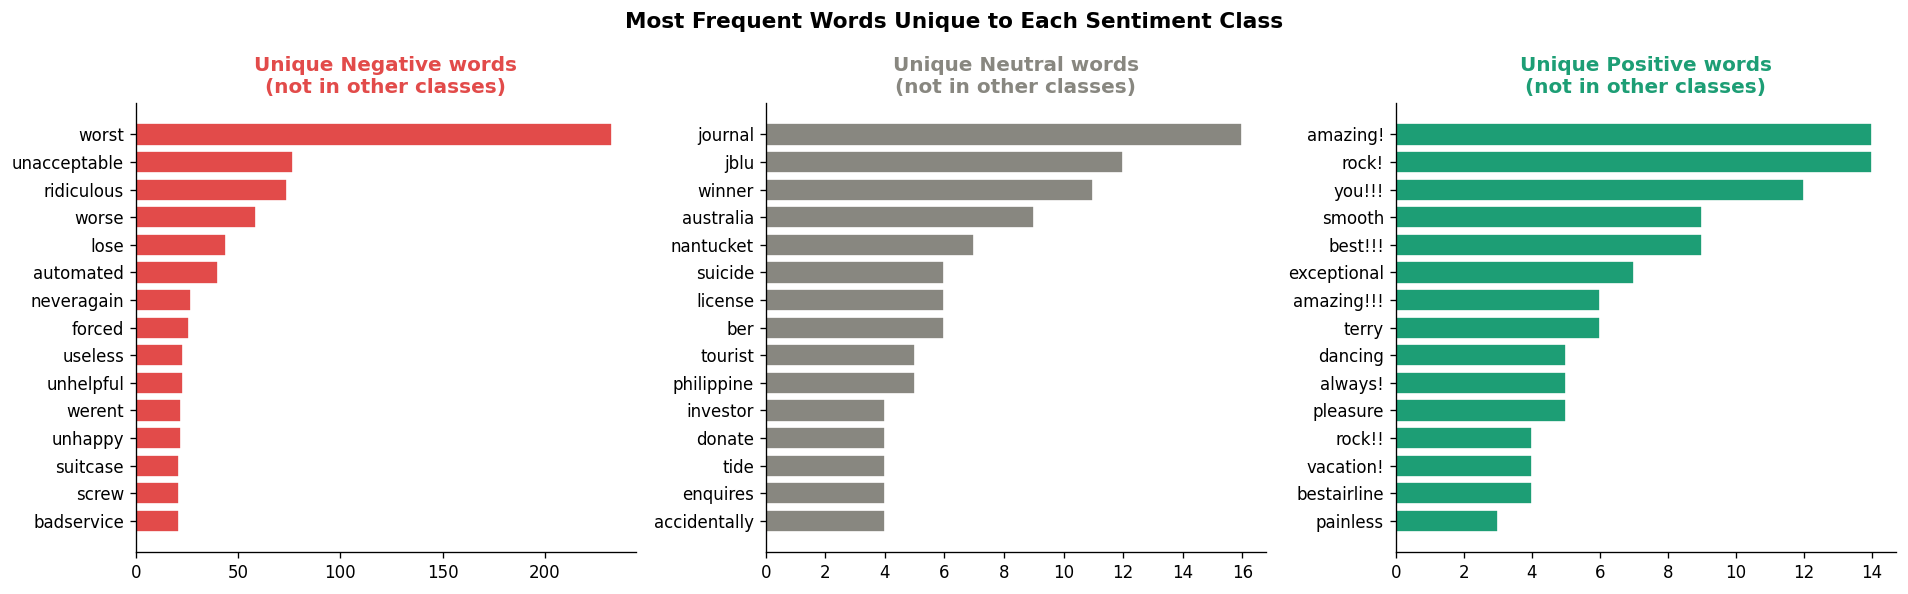

Unique to negative : 6,013 words
Unique to neutral  : 1,613 words
Unique to positive : 1,503 words


In [8]:
# Words UNIQUE to each sentiment — these are the most discriminative features
def unique_words(target_vocab, other_vocabs):
    others = set().union(*other_vocabs)
    return target_vocab - others

neg_unique = unique_words(neg_vocab, [neu_vocab, pos_vocab])
neu_unique = unique_words(neu_vocab, [neg_vocab, pos_vocab])
pos_unique = unique_words(pos_vocab, [neg_vocab, neu_vocab])

# Get frequency of unique words
def top_unique(sentiment, unique_set, n=15):
    words = df[df["airline_sentiment"]==sentiment]["final_text"].dropna()
    all_words = " ".join(words).split()
    freq = Counter(w for w in all_words if w in unique_set)
    return freq.most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, sentiment, unique_set, color in zip(
    axes,
    ["negative","neutral","positive"],
    [neg_unique, neu_unique, pos_unique],
    ["#E24B4A","#888780","#1D9E75"]
):
    top = top_unique(sentiment, unique_set)
    if top:
        words, counts = zip(*top)
        ax.barh(words[::-1], counts[::-1], color=color, edgecolor="white")
        ax.set_title(f"Unique {sentiment.capitalize()} words\n(not in other classes)",
                     fontweight="bold", color=color)
        ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Most Frequent Words Unique to Each Sentiment Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_vocabulary_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Unique to negative : {len(neg_unique):,} words")
print(f"Unique to neutral  : {len(neu_unique):,} words")
print(f"Unique to positive : {len(pos_unique):,} words")

## 8. Correlation Analysis

Which numerical features correlate with sentiment?
This tells us which columns might be useful as additional model features.


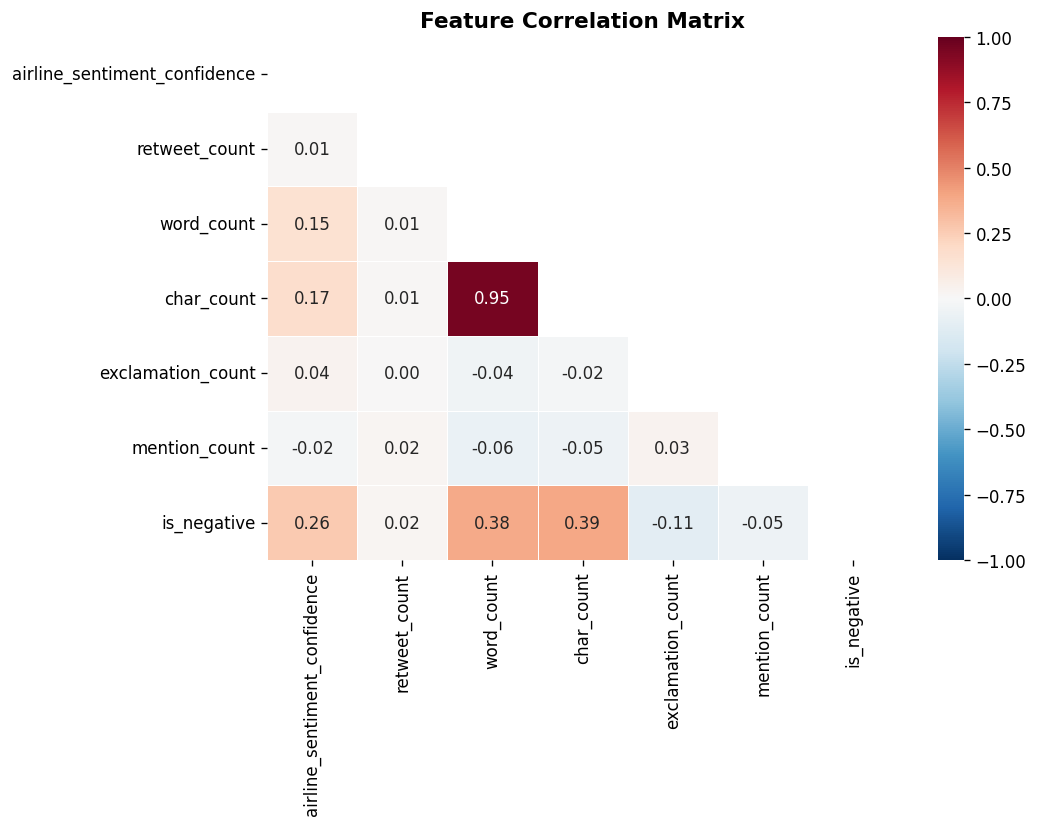

Correlation with negative sentiment:
  exclamation_count                   -0.106  ↓ less likely negative
  mention_count                       -0.051  ↓ less likely negative
  retweet_count                       +0.018  ↑ more likely negative
  airline_sentiment_confidence        +0.264  ↑ more likely negative
  word_count                          +0.379  ↑ more likely negative
  char_count                          +0.389  ↑ more likely negative


In [9]:
# Build numerical features
df_num = df.copy()
df_num["is_negative"] = (df["airline_sentiment"]=="negative").astype(int)
df_num["exclamation_count"] = df["clean_text"].str.count("!")
df_num["mention_count"]     = df["text"].str.count("@")
df_num["has_negativereason"] = df["negativereason"].notna().astype(int)

num_cols = ["airline_sentiment_confidence","retweet_count","word_count",
            "char_count","exclamation_count","mention_count","is_negative"]

corr = df_num[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, mask=mask, linewidths=0.5,
            linecolor="white", vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation with is_negative
target_corr = corr["is_negative"].drop("is_negative").sort_values()
print("Correlation with negative sentiment:")
for feat, val in target_corr.items():
    direction = "↑ more likely negative" if val > 0 else "↓ less likely negative"
    print(f"  {feat:<35} {val:+.3f}  {direction}")

## 9. Label Confidence Analysis

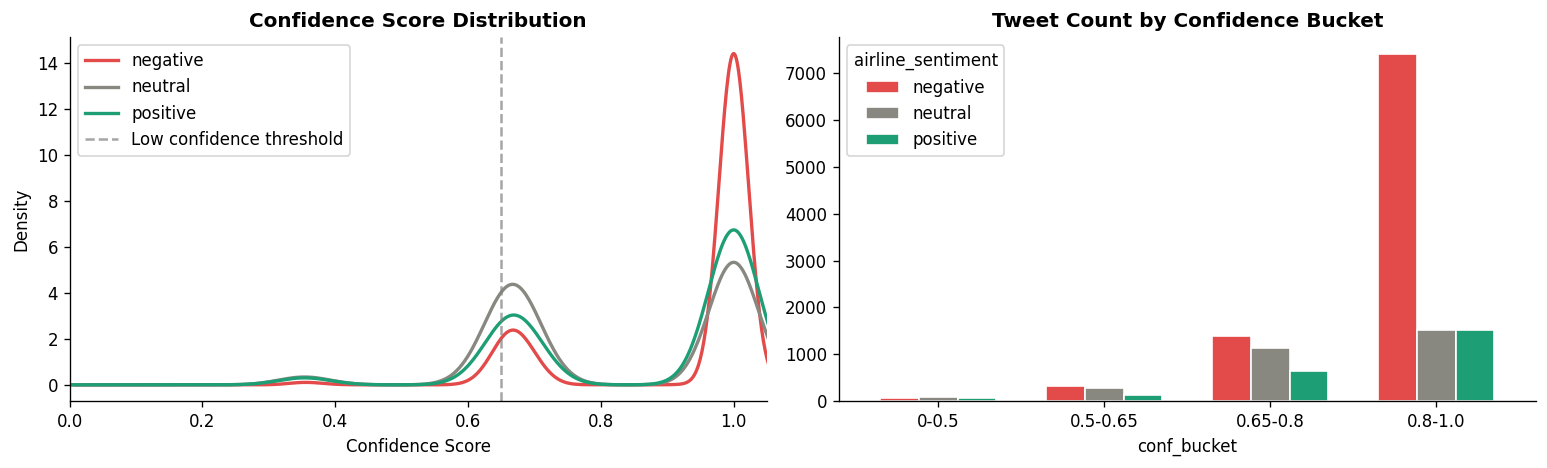

Low confidence labels (<0.65) : 972 (6.7%)
These are the hardest tweets to classify — expect model errors here.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution by sentiment
for s in ["negative","neutral","positive"]:
    df[df["airline_sentiment"]==s]["airline_sentiment_confidence"].plot.kde(
        ax=axes[0], color=PALETTE[s], linewidth=2, label=s)
axes[0].axvline(x=0.65, color="gray", linestyle="--", alpha=0.7,
                label="Low confidence threshold")
axes[0].set_title("Confidence Score Distribution", fontweight="bold")
axes[0].set_xlabel("Confidence Score")
axes[0].legend(); axes[0].set_xlim(0, 1.05)
axes[0].spines[["top","right"]].set_visible(False)

# Accuracy by confidence bucket
df["conf_bucket"] = pd.cut(df["airline_sentiment_confidence"],
                            bins=[0, 0.5, 0.65, 0.8, 1.0],
                            labels=["0-0.5","0.5-0.65","0.65-0.8","0.8-1.0"])
conf_counts = df.groupby(["conf_bucket","airline_sentiment"]).size().unstack(fill_value=0)
conf_counts.plot(kind="bar", ax=axes[1],
                 color=[PALETTE[s] for s in ["negative","neutral","positive"]],
                 edgecolor="white", width=0.7)
axes[1].set_title("Tweet Count by Confidence Bucket", fontweight="bold")
axes[1].tick_params(axis="x", rotation=0)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/01_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

low_conf = (df["airline_sentiment_confidence"] < 0.65).sum()
print(f"Low confidence labels (<0.65) : {low_conf:,} ({low_conf/len(df)*100:.1f}%)")
print("These are the hardest tweets to classify — expect model errors here.")


## 10. Word Clouds

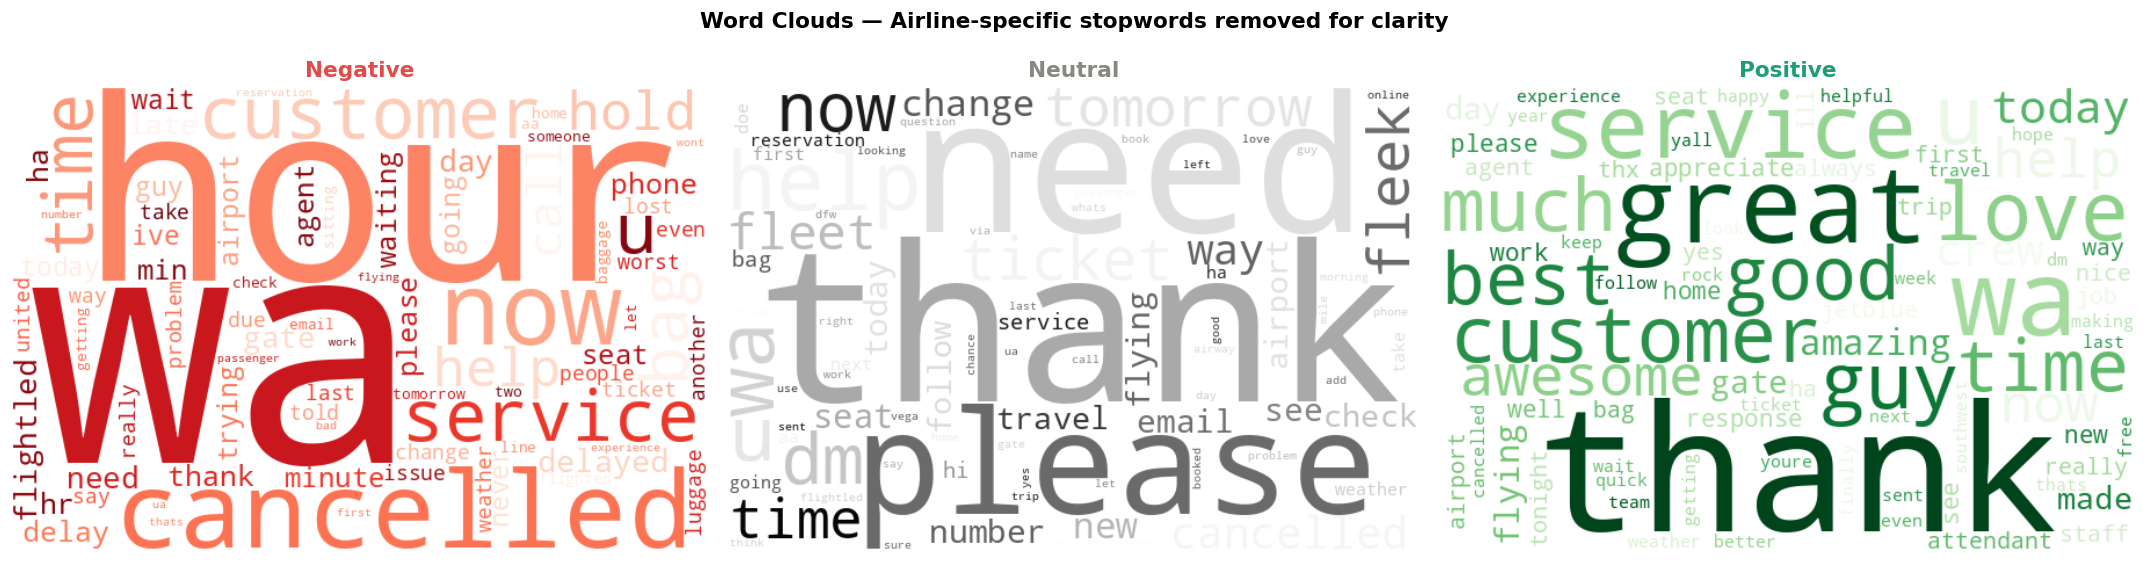

In [11]:
# Airline-specific stopwords — these dominate but add no sentiment info
airline_stops = {"flight","airline","fly","plane","air","get","us","amp",
                 "would","could","will","one","also","still","back","im",
                 "dont","cant","didnt","got","go","know","make","want"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = {"negative":"Reds","neutral":"Greys","positive":"Greens"}

for ax, sentiment in zip(axes, ["negative","neutral","positive"]):
    text = " ".join(df[df["airline_sentiment"]==sentiment]["final_text"].dropna())
    # Remove airline-specific stops for cleaner clouds
    text = " ".join(w for w in text.split() if w not in airline_stops)
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmaps[sentiment], max_words=80,
                   collocations=False).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sentiment.capitalize()}", fontsize=13,
                 fontweight="bold", color=PALETTE[sentiment])

fig.suptitle("Word Clouds — Airline-specific stopwords removed for clarity",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/01_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Key Business Insights

In [12]:
print("="*65)
print("KEY BUSINESS INSIGHTS")
print("="*65)

neg_pct  = (df["airline_sentiment"]=="negative").mean()*100
worst    = df[df["airline_sentiment"]=="negative"]["airline"].value_counts().idxmax()
best     = (df.groupby("airline")["airline_sentiment"]
              .apply(lambda x: (x=="negative").mean()*100)
              .idxmin())
top_r    = df[df["airline_sentiment"]=="negative"]["negativereason"].value_counts().index[0]
peak_h   = df.groupby("hour")["airline_sentiment"].apply(
               lambda x: (x=="negative").mean()).idxmax()
neg_wc   = df[df["airline_sentiment"]=="negative"]["word_count"].mean()
pos_wc   = df[df["airline_sentiment"]=="positive"]["word_count"].mean()
overlap  = len(neg_vocab & neu_vocab & pos_vocab)

print(f"1. {neg_pct:.0f}% of tweets are negative — Twitter skews toward complaints.")
print(f"2. {worst} has the highest negative volume.")
print(f"   {best} has the lowest negative rate — benchmark airline.")
print(f"3. Top complaint: '{top_r}' — directly actionable for operations.")
print(f"4. Peak complaint hour: {peak_h}:00 UTC — staff customer service accordingly.")
print(f"5. Negative tweets avg {neg_wc:.1f} words vs {pos_wc:.1f} for positive.")
print(f"   Complaints are more detailed — customers elaborate when unhappy.")
print(f"6. {overlap:,} words shared across ALL three sentiment classes.")
print(f"   High overlap = neutral class will be hardest to classify.")
print(f"7. Low confidence labels will be hardest for the model to get right.")
print("="*65)

KEY BUSINESS INSIGHTS
1. 63% of tweets are negative — Twitter skews toward complaints.
2. United has the highest negative volume.
   Virgin America has the lowest negative rate — benchmark airline.
3. Top complaint: 'Customer Service Issue' — directly actionable for operations.
4. Peak complaint hour: 8:00 UTC — staff customer service accordingly.
5. Negative tweets avg 18.0 words vs 12.5 for positive.
   Complaints are more detailed — customers elaborate when unhappy.
6. 1,888 words shared across ALL three sentiment classes.
   High overlap = neutral class will be hardest to classify.
7. Low confidence labels will be hardest for the model to get right.
